In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.utils import bin_distances
from matplotlib import cm

/opt/conda/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


# Plaque Pathology Distance Plots

In [2]:
plaque_adata = sc.read_h5ad("/root/capsule/data/path_adata/seaad_cah_plaque_distance_adata.2026-02-06.h5ad")
plaque_adata = plaque_adata[plaque_adata.obs['Used in analysis']]

In [3]:
covariate = "nearest_plaque_distance"
distances = plaque_adata.obs[covariate]
plaque_adata.obs[f"{covariate}_binned"] = bin_distances(distances, 5)

/tmp/ipykernel_9891/2714027419.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  plaque_adata.obs[f"{covariate}_binned"] = bin_distances(distances, 5)


In [4]:
custom_palette = {
    'Astrocyte': '#FFC300',
    'Microglia-PVM': '#FF5733',
    'VLMC': '#5DADE2',
    'Endothelial': '#AED6F1',
    'Sst Chodl': '#27AE60',
    'CN ST18 GABA': '#A9DFBF',
    'STR D1 MSN': '#8E44AD',
    'STR D2 MSN': '#D2B4DE',
    'STR Hybrid MSN': '#E8DAEF',
    'OPC': '#FAD7A0',
    'Oligodendrocyte': '#D35400',
    'Ependymal':"#564860",
    'STR RSPO2 GABA':'#5b0e63',
    'Vip': '#1bc06a',
    'CN LAMP5-CXCL14 GABA':'#f6b5d1',
                 }

## Figure 4G

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9891/3709972446.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel(f"{" ".join(covariate.split("_")[:3]).capitalize()} - $\mu m$")


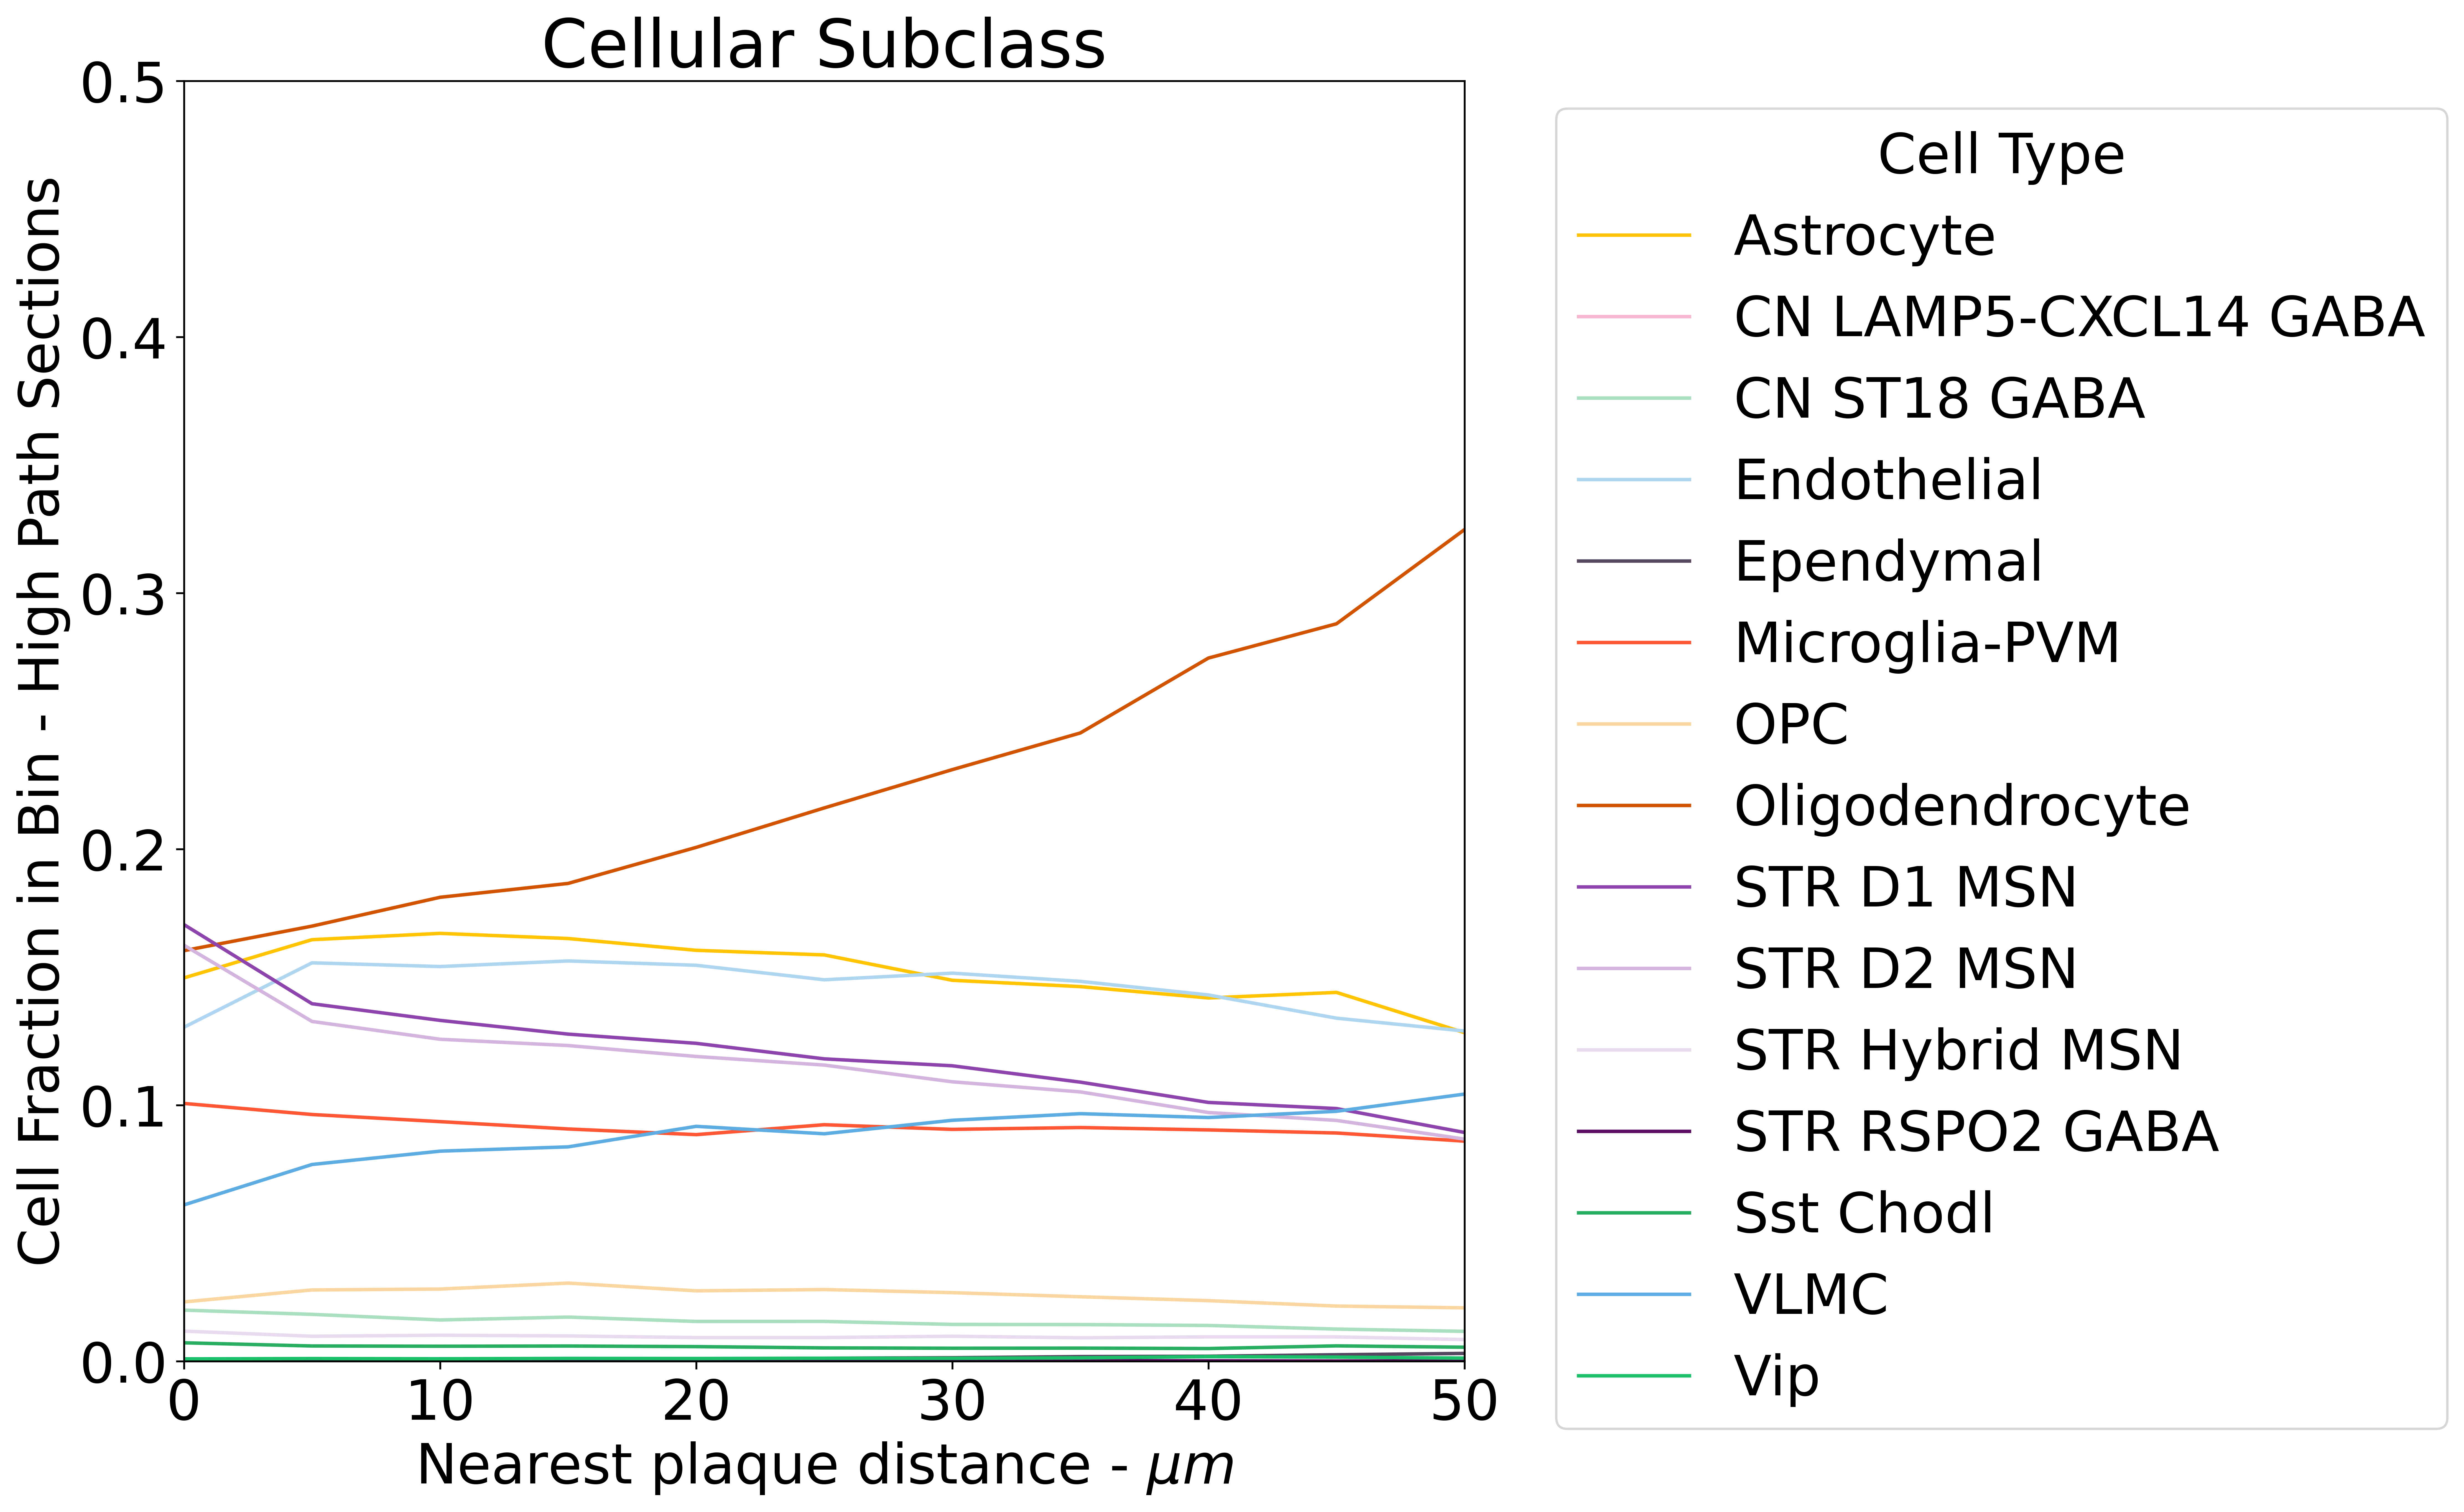

In [5]:
# digitizing plaque distances in 5 mum bins

metadata_section_nn = plaque_adata.obs.copy()
# metadata_section = metadata[metadata["barcode"] == str(barcode)].copy()
# metadata_section_nn = metadata_section[metadata_section["Subclass_scANVI"]].copy()#[~metadata_section["CAH_Class_label_name"].isin(neuronal_classes)].copy()
metadata_section_nn["cell_labels"] = metadata_section_nn["Subclass"].astype(str).str.replace("_Subclass", "")
# metadata_section_nn.loc[metadata_section_nn["QC Passed"] == False, "cell_labels"] = "QC Failed"
binned_counts = metadata_section_nn.groupby(f"{covariate}_binned")["cell_labels"].value_counts(normalize = True).unstack().fillna(0)
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    ax = sns.lineplot(data=binned_counts, dashes=False, palette=custom_palette,)
    plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 50)
    plt.ylim(0, 0.5)
    if covariate.startswith("cellular"):
        covariate = covariate.replace("cellular", "globular")
    plt.xlabel(f"{" ".join(covariate.split("_")[:3]).capitalize()} - $\mu m$")
    plt.ylabel("Cell Fraction in Bin - High Path Sections")
    plt.title(f"")
    ax.set_aspect(np.diff(ax.get_xlim())/np.diff(ax.get_ylim()))
    plt.title("Cellular Subclass")
    # plt.savefig(
    # f'/scratch/Figure6_path_enrichment_lineplot_subclass_{covariate}.svg',
    # bbox_inches='tight',
    # )    
    plt.show()

In [6]:
microglia_palette = {'Micro-PVM_2': cm.tab10.colors[1],
 'Micro-PVM_2_3-SEAAD': cm.tab10.colors[2],
 'Micro-PVM_3-SEAAD': cm.tab10.colors[3],
 'Micro-PVM_1': cm.tab10.colors[0],
 'Lymphocyte': '#fe99a0',
 'Micro-PVM_2_1-SEAAD': '#ffb8c0',
 'Monocyte': '#ffd6df',
 'Micro-PVM_4-SEAAD': '#fff5ff'}

## Supplemental Figure 3D

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_9891/1945971274.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel(f"{" ".join(covariate.split("_")[:2]).capitalize()} - $\mu m$")


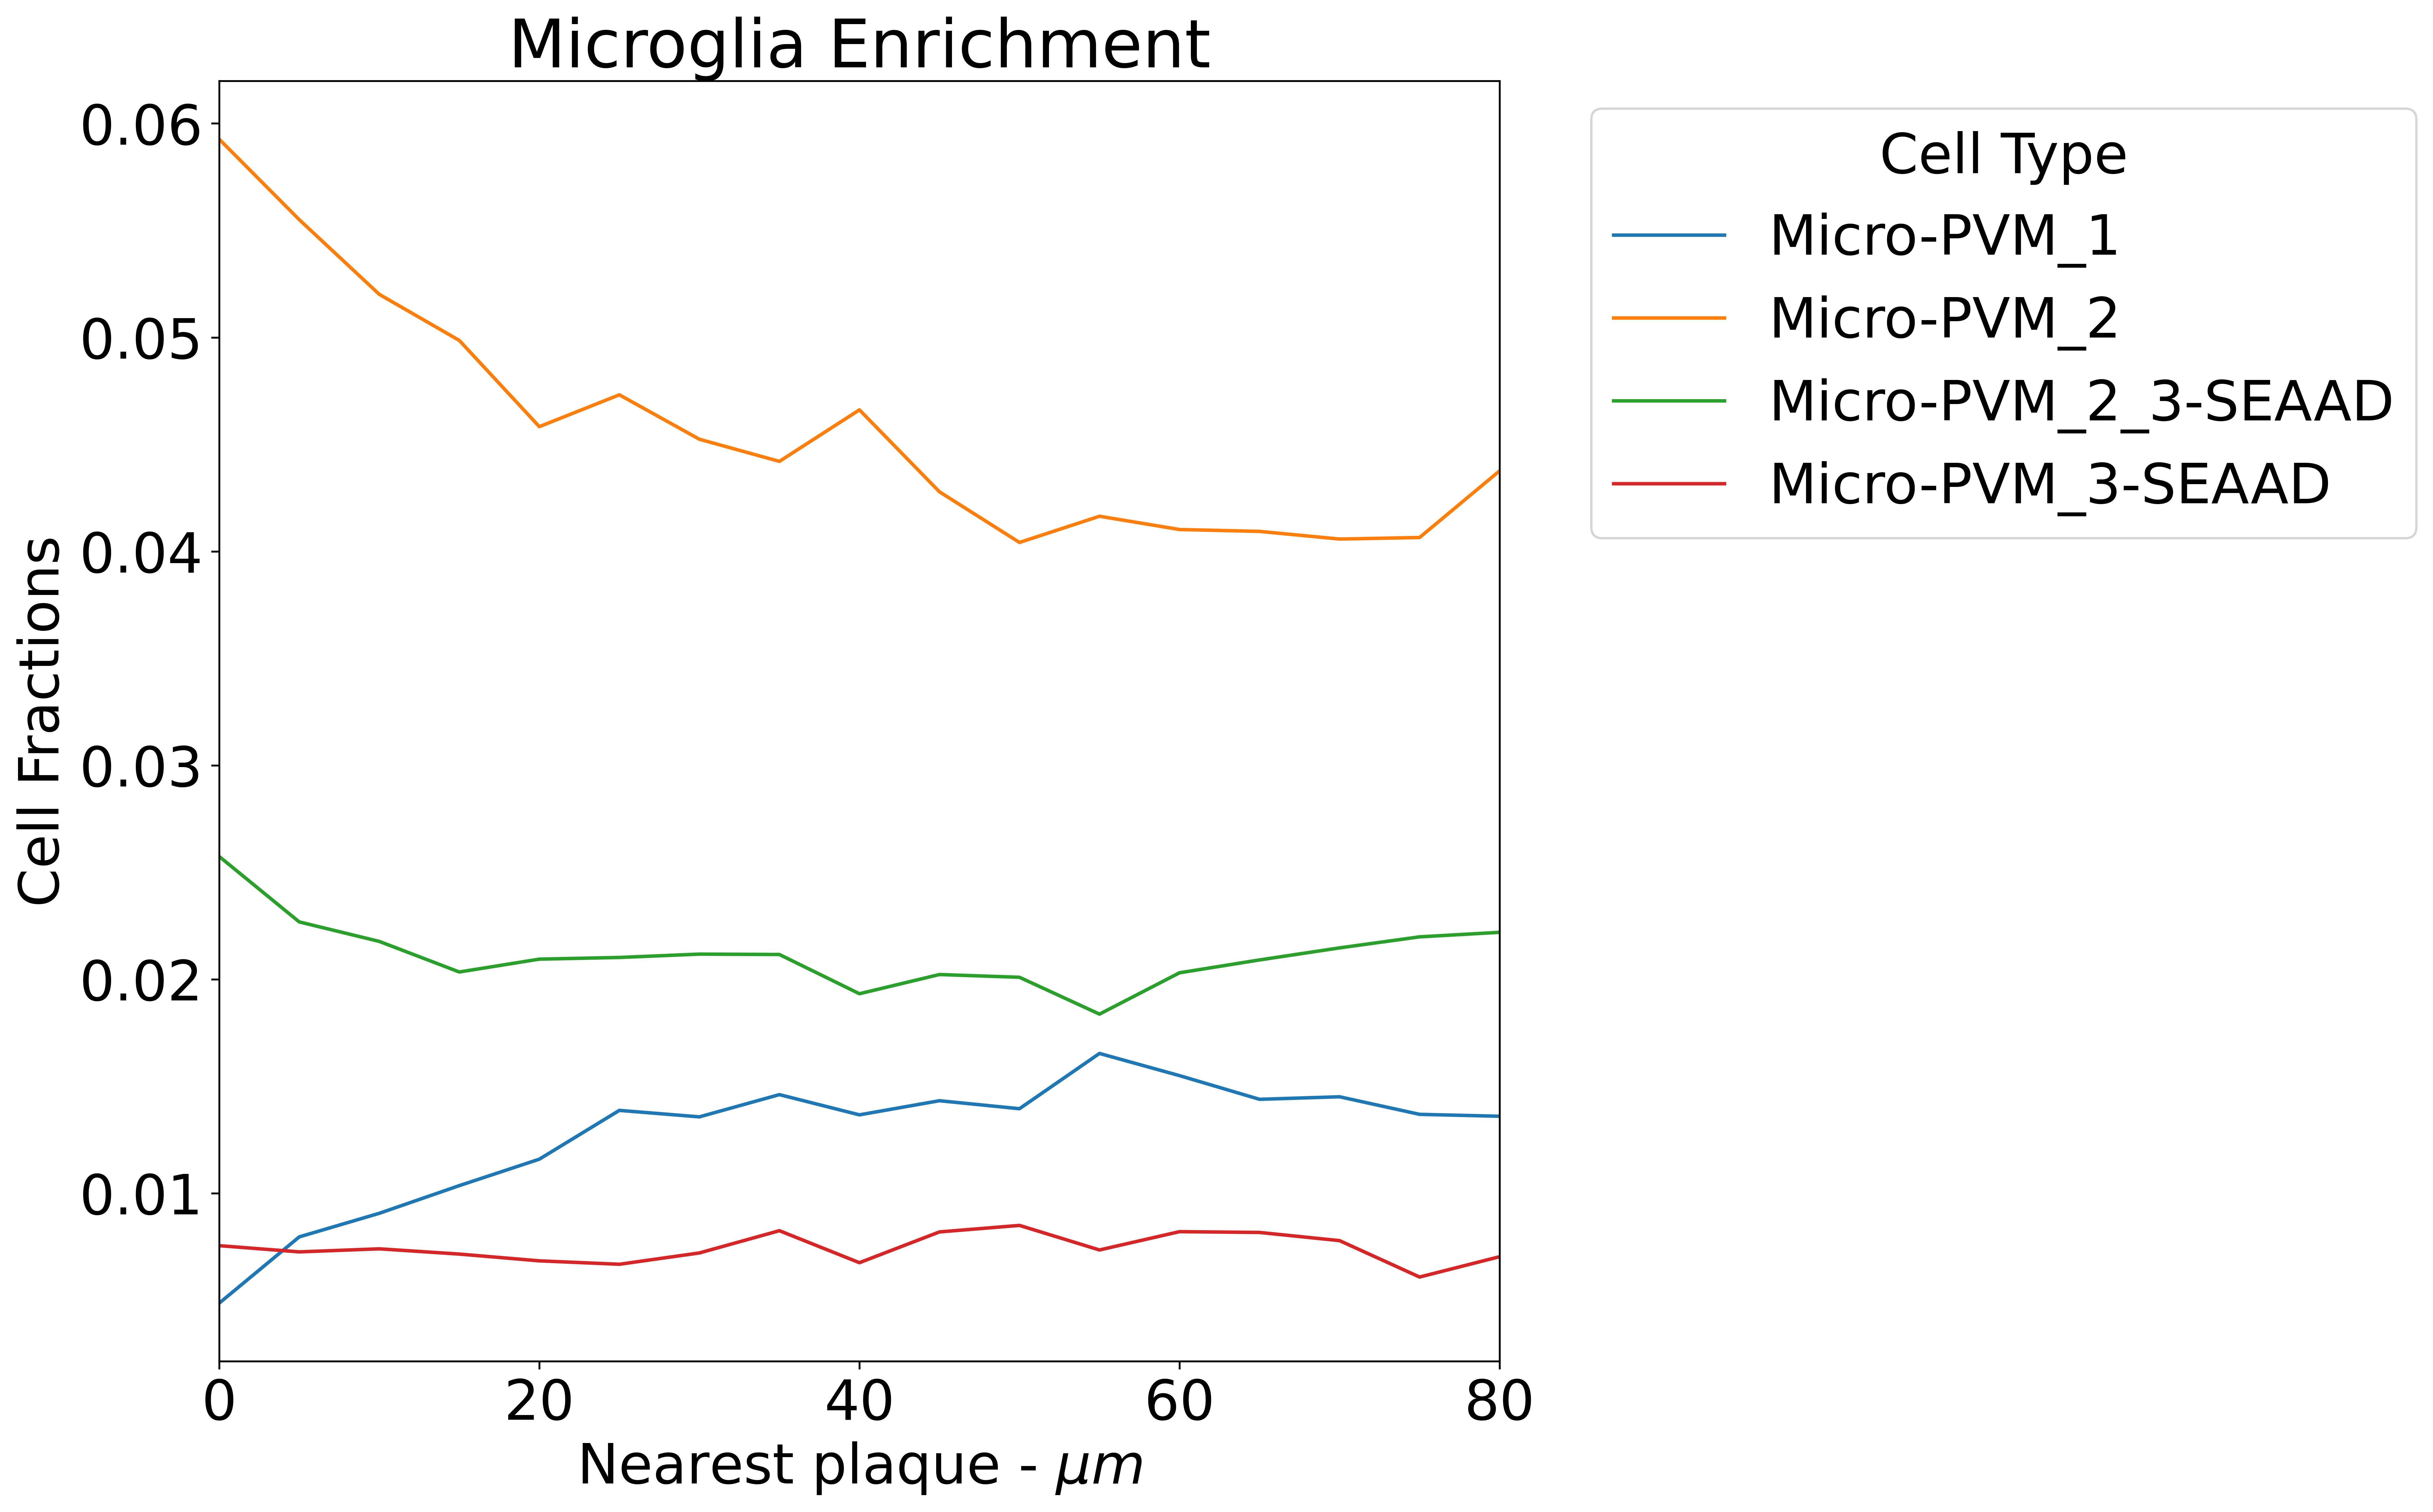

In [7]:
# digitizing plaque distances in 10 mum bins
metadata_section_nn = plaque_adata.obs.copy()
metadata_section_nn["cell_labels"] = metadata_section_nn["Supertype"].astype(str).str.replace("_Supertype", "")
# metadata_section_nn.loc[metadata_section_nn["QC Passed"] == False, "cell_labels"] = "QC Failed"
binned_counts = metadata_section_nn.groupby(f"{covariate}_binned")["cell_labels"].value_counts(normalize = True).unstack().fillna(0)
binned_counts = binned_counts.loc[binned_counts.index <= 80]
with plt.rc_context({'figure.figsize':(10, 10), 'figure.dpi':600, 'font.size':24}):
    ax = sns.lineplot(data=binned_counts[binned_counts.columns[binned_counts.columns.isin(['Micro-PVM_1',
    'Micro-PVM_2',
    'Micro-PVM_2_3-SEAAD',
    'Micro-PVM_3-SEAAD',])]], dashes=False, palette=microglia_palette,)
    plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 80)
    if covariate.startswith("cellular"):
        covariate = covariate.replace("cellular", "globular")

    plt.xlabel(f"{" ".join(covariate.split("_")[:2]).capitalize()} - $\mu m$")
    plt.ylabel("Cell Fractions")
    plt.title(f"Microglia Enrichment")
    ax.set_aspect(np.diff(ax.get_xlim())/np.diff(ax.get_ylim()))
    plt.show()

# Ptau Pathology Distance Plots